# Master MIND - IDLE

# Modèles récurrents

------------------------------------------------------------------------

**Préparation**

Pour simplifier, voici une implémentation pour charger le dataset:

-   Chargement des données depuis HuggingFace
-   Pré-traitement de base, et découpage des mots, récupération des plus
    fréquents
-   Encodage des mots par des entiers
-   Emballage dans un Dataset `torch`

In [ ]:
from datasets import load_dataset
import re
from collections import Counter
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
from torch import optim
import matplotlib.pyplot as plt


from tqdm.auto import trange

In [15]:
dataset = load_dataset("imdb")

def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

def build_vocab(dataset_iter, max_vocab_size=10000):
    counter = Counter()
    for item in dataset_iter:
        tokens = tokenize(item['text'])
        counter.update(tokens)
    
    # Mots les plus fréquents
    # Padding <pad>
    # Mots inconnus <unk>
    most_common = counter.most_common(max_vocab_size)
    vocab = {'<pad>': 0, '<unk>': 1}
    for word, _ in most_common:
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(dataset['train'])

In [16]:
vocab

{'<pad>': 0,
 '<unk>': 1,
 'the': 2,
 'and': 3,
 'a': 4,
 'of': 5,
 'to': 6,
 'is': 7,
 'in': 8,
 'it': 9,
 'i': 10,
 'this': 11,
 'that': 12,
 'br': 13,
 'was': 14,
 'as': 15,
 'for': 16,
 'with': 17,
 'movie': 18,
 'but': 19,
 'film': 20,
 'on': 21,
 'not': 22,
 'you': 23,
 'are': 24,
 'his': 25,
 'have': 26,
 'he': 27,
 'be': 28,
 'one': 29,
 'its': 30,
 'at': 31,
 'all': 32,
 'by': 33,
 'an': 34,
 'they': 35,
 'from': 36,
 'who': 37,
 'so': 38,
 'like': 39,
 'her': 40,
 'just': 41,
 'or': 42,
 'about': 43,
 'has': 44,
 'if': 45,
 'out': 46,
 'some': 47,
 'there': 48,
 'what': 49,
 'good': 50,
 'when': 51,
 'more': 52,
 'very': 53,
 'even': 54,
 'she': 55,
 'my': 56,
 'no': 57,
 'up': 58,
 'would': 59,
 'which': 60,
 'only': 61,
 'time': 62,
 'really': 63,
 'story': 64,
 'their': 65,
 'were': 66,
 'had': 67,
 'see': 68,
 'can': 69,
 'me': 70,
 'than': 71,
 'we': 72,
 'much': 73,
 'well': 74,
 'been': 75,
 'get': 76,
 'will': 77,
 'into': 78,
 'also': 79,
 'because': 80,
 'other': 81

In [17]:
def encode_and_pad(text, vocab, max_len=200):
    tokens = tokenize(text)
    encoded = [ vocab.get(token, vocab['<unk>']) for token in tokens ]

    if len(encoded) > max_len:
        encoded = encoded[:max_len]
    else:
        encoded = [vocab['<pad>']] * (max_len - len(encoded)) + encoded # NOTE: did left padding instead

    return torch.tensor(encoded, dtype=torch.long)

class IMDBDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len=200):
        self.dataset = hf_dataset
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        text = self.dataset[idx]['text']
        label = self.dataset[idx]['label']
        x = encode_and_pad(text, self.vocab, self.max_len)
        y = torch.tensor(label, dtype=torch.float)
        return x, y

train_dataset = IMDBDataset(dataset['train'], vocab)
test_dataset = IMDBDataset(dataset['test'], vocab)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Exercice 1 - *Architecture* *RNN*

L’objectif est de construire un modèle de classification de sentiments
basique.

## Question 1

Construire une architecture simple:

-   une couche d’embedding `nn.Embedding`, initialisée aléatoirement
    (donc à apprendre),
-   une couche récurrent `nn.RNN` dont on récupérera l’état caché pour
    le passer à la couche suivante,;
-   une couche linéaire pour la classification finale

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size=2, num_layers=1):
        super().__init__()

        # TODO: as if we had one hot encoded inputs and it was a first layer,
        # but instead of doing this matix multiplication with a sparse vector, 
        # that is the same as selecting a row of that weight matrix,
        # nn.Embedding implements a kind of dictionary - more efficient?
        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.RNN(input_size=embed_size, hidden_size=hidden_size, batch_first=True, num_layers=num_layers)

        self.fc = nn.Linear(hidden_size,output_size)
    
    def forward(self, x, h0=None):
        embedded = self.embedding(x)
        rnn_out, h_n = self.rnn(embedded, h0)
        # logits = self.fc(rnn_out[:,-1,:]) # note that no non-linearity applied here, just matrix multiplication
        logits = self.fc(h_n[-1]) # h_n - hidden layers at last timestep, [-1] - last hidden layer
        return logits

## Question 2

Entraîner et évaluer cette architecture (en train, en test, en analysant
les courbes d’apprentissage).

In [52]:
def train_model(model, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    num_epochs = 10
    train_losses = []
    test_losses = []
    train_scores = []
    test_scores = []

    for epoch in trange(num_epochs):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            outputs = model(batch_x)

            loss = criterion(outputs, batch_y.long())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * batch_y.size(0)

            # TODO: loss
        train_losses.append(epoch_loss / len(train_loader.dataset))

        model.eval()
        test_epoch_loss = 0
        with torch.no_grad():
            correct = total = 0
            for batch_x, batch_y in train_loader:
                outputs = model(batch_x)
                y_pred = outputs.argmax(-1)
                total += batch_y.size(0)
                correct += (y_pred == batch_y).sum().item()
            train_scores.append(correct / total)
            correct = total = 0
            for batch_x, batch_y in test_loader:
                outputs = model(batch_x)
                test_epoch_loss += criterion(outputs, batch_y.long()).item() * batch_y.size(0)
                y_pred = outputs.argmax(-1)
                total += batch_y.size(0) 
                correct += (y_pred == batch_y).sum().item()
            test_losses.append(test_epoch_loss / len(test_loader.dataset))
            test_scores.append(correct / total)
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    axes = axes.flatten()
    axes[0].set_title("Evolution of loss during training")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].plot(train_losses, label="train")
    axes[0].plot(test_losses, label="test")
    axes[0].legend()

    axes[1].set_title("Evolution of score during training")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("score")
    axes[1].plot(train_scores, label="train")
    axes[1].plot(test_scores, label="test")
    axes[1].legend()
    plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

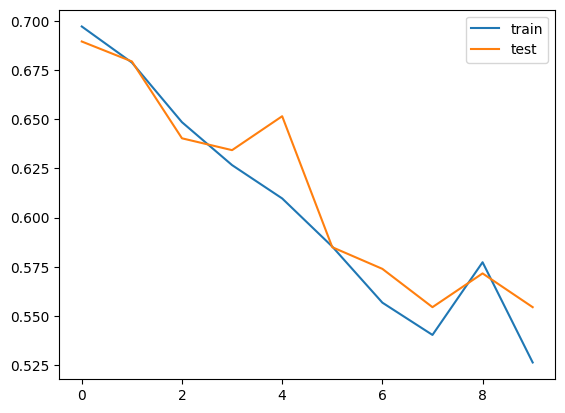

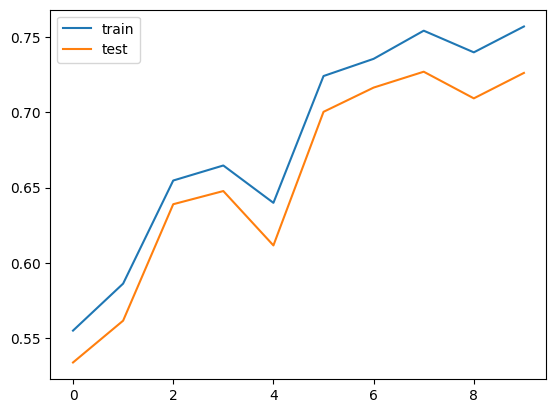

In [32]:
train_model(SimpleRNN(vocab_size = len(vocab), embed_size=128, hidden_size=128))

## Question 3

Adapter le module PyTorch pour que le nombre de couche récurrentes
devienne un hyper-paramètre.

Expérimenter avec différentes profondeurs

**Note**: avec `nn.RNN` il suffit d’utiliser l’argument `num_layers`
pour empiler plusieurs couches.

  0%|          | 0/10 [00:00<?, ?it/s]

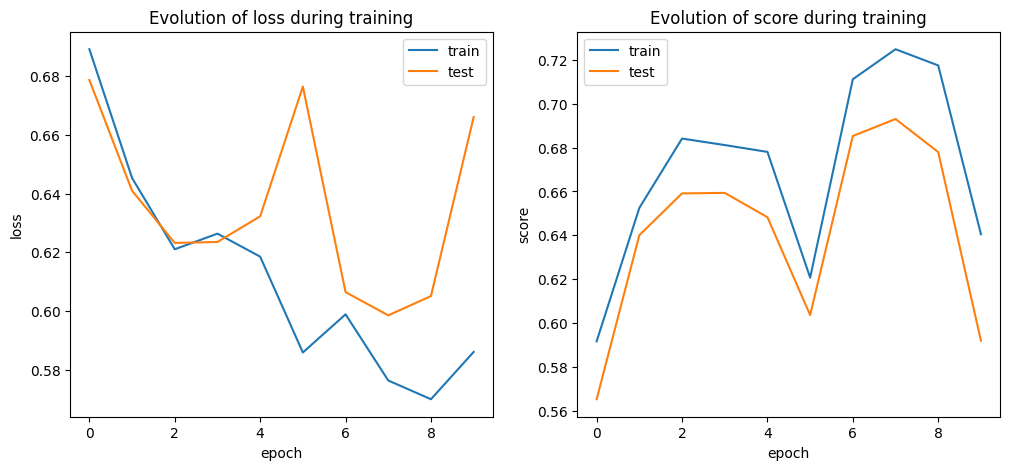

In [53]:
train_model(SimpleRNN(vocab_size = len(vocab), embed_size=128, hidden_size=128, num_layers=2))

# Exercice 2 - *Comparaison* *avec* *LSTM* *et* *GRU*

## Question 4

Adapter le module précédent pour utiliser une ou plusieurs couches LSTM.
Analyser les performances.

In [57]:
class SimpleLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size=2, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.LSTM(input_size=embed_size, hidden_size=hidden_size, batch_first=True, num_layers=num_layers)

        self.fc = nn.Linear(hidden_size,output_size)
    
    def forward(self, x, h0=None):
        embedded = self.embedding(x)
        rnn_out, (h_n, c_n) = self.rnn(embedded, h0)
        logits = self.fc(h_n[-1])
        return logits

  0%|          | 0/10 [00:00<?, ?it/s]

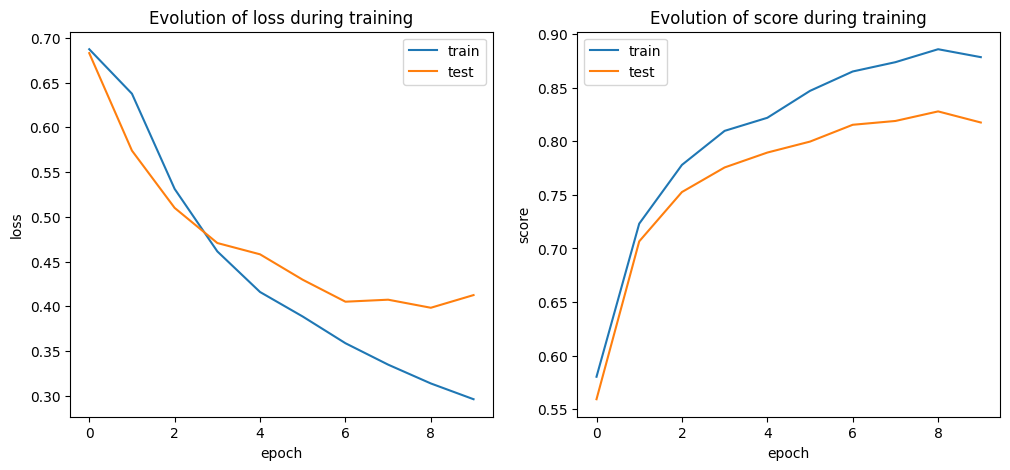

In [58]:
train_model(SimpleLSTM(vocab_size = len(vocab), embed_size=128, hidden_size=128, num_layers=1))

## Question 5

Même question avec GRU (une variante de LSTM).

In [61]:
class SimpleGRU(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size=2, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.GRU(input_size=embed_size, hidden_size=hidden_size, batch_first=True, num_layers=num_layers)

        self.fc = nn.Linear(hidden_size,output_size)
    
    def forward(self, x, h0=None):
        embedded = self.embedding(x)
        rnn_out, h_n = self.rnn(embedded, h0)
        logits = self.fc(h_n[-1])
        return logits

  0%|          | 0/10 [00:00<?, ?it/s]

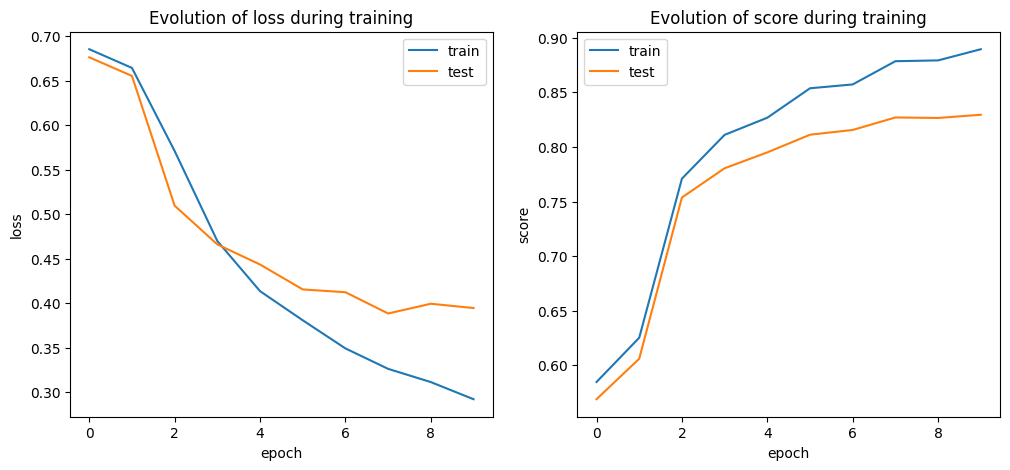

In [62]:
train_model(SimpleGRU(vocab_size = len(vocab), embed_size=128, hidden_size=128, num_layers=1))

# Exercice 3 - *Embeddings* *pré-entraînés*

Au lieu d’apprendre les représentations des mots à partir d’une
initialisation aléatoir, nous allons utiliser des vecteurs GloVe
pré-entraînés.

In [65]:
import gensim.downloader
embeddings = gensim.downloader.load("glove-wiki-gigaword-100")

## Question 6

L’embedding est utilisable comme un dictionnaire

In [66]:
embeddings["that"]

array([-9.3337e-02,  1.9043e-01,  6.8457e-01, -4.1548e-01, -2.2777e-01,
       -1.1803e-01, -9.5434e-02,  1.9613e-01,  1.7785e-01, -2.0244e-02,
       -5.5409e-02,  3.3867e-01,  7.9396e-01, -4.7126e-02,  4.4281e-01,
       -6.1266e-02,  2.0796e-01,  3.4094e-02, -6.4751e-01,  3.5874e-01,
        1.3936e-01, -6.8310e-01,  2.5596e-01, -1.2911e-01,  2.6080e-01,
       -1.1674e-01,  2.4925e-02, -6.0259e-01, -4.1474e-01, -5.1104e-01,
        1.4936e-01,  7.9977e-01, -1.2716e-01,  4.0474e-01, -2.1435e-01,
        4.7031e-01,  4.9000e-01,  4.8886e-01, -1.7772e-01, -1.8861e-01,
       -7.8391e-01, -1.4158e-01,  2.2169e-01, -2.2078e-01, -3.0509e-01,
       -1.0837e-01,  5.7168e-01, -7.8320e-01, -1.6328e-01, -7.6131e-01,
        8.0873e-02,  6.7217e-04,  4.4713e-01,  1.3434e+00, -2.0014e-01,
       -2.8680e+00, -2.6470e-03, -3.9858e-01,  1.8379e+00,  1.2211e+00,
       -1.6066e-01,  6.5853e-01,  2.6946e-01,  2.7212e-01,  9.4735e-01,
        2.4372e-01,  8.1940e-01,  6.7740e-01,  6.3485e-02, -5.59

Pour l’utiliser dans une architecture PyTorch, on doit récupérer les
représentations de tous les mots du vocabulaire et construire un
tenseur.

Nous devons donc créer une matrice de taille
`(vocab_size, embedding_dim)` où chaque ligne correspond au vecteur de
représentation GloVe du mot (ou zéro si inconnu).

In [73]:
vocab_dim = len(vocab)
embed_dim = len(embeddings["the"])
embedding_matrix = torch.empty((vocab_dim, embed_dim))
for word, idx in vocab.items():
    if word in embeddings:
        embedding_matrix[idx] = torch.tensor(embeddings[word])
    else:
        embedding_matrix[idx] = torch.zeros(embed_dim)
        
embedding_matrix.requires_grad = False

## Question 7

Dans les architectures précédentes, utiliser la matrice précédente comme
initialisation de la couche d’embedding.

On n’oubliera pas de figer les poids de cette couche pour ne pas les
modifier lors de l’apprentissage.

In [84]:
class GRUWithGloVe(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, output_size=2, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

        self.rnn = nn.GRU(input_size=embedding_matrix.shape[1], hidden_size=hidden_size, batch_first=True, num_layers=num_layers)

        self.fc = nn.Linear(hidden_size,output_size)
    
    def forward(self, x, h0=None):
        embedded = self.embedding(x)
        rnn_out, h_n = self.rnn(embedded, h0)
        logits = self.fc(h_n[-1])
        return logits

  0%|          | 0/10 [00:00<?, ?it/s]

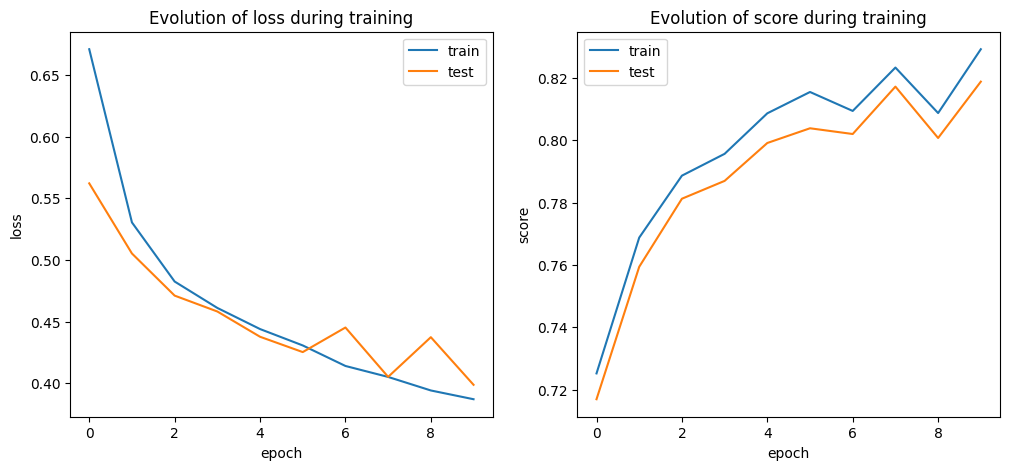

In [85]:
train_model(GRUWithGloVe(embedding_matrix, hidden_size=128, num_layers=1))

## Question 8

Comparer les performances avec les modèles précédents.

# Exercice 4 - *Observation* *du* *vanishing* *gradient*

Le but de cet exercice est de constater expérimentalement le phénomène
de disparition du gradient dans des architectures profondes et
d’analyser l’impacts des différentes couches récurentes (RNN simple,
LSTM et GRU).

La documentation de
[`nn.RNN`](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html)
nous apprend le nom des attributs du module qui stockent les paramètres.

> Variables:
>
> -   weight_ih_l\[k\] – the learnable input-hidden weights of the k-th
>     layer, of shape (hidden_size, input_size) for k = 0. Otherwise,
>     the shape is (hidden_size, num_directions \* hidden_size)
> -   weight_hh_l\[k\] – the learnable hidden-hidden weights of the k-th
>     layer, of shape (hidden_size, hidden_size)
> -   bias_ih_l\[k\] – the learnable input-hidden bias of the k-th
>     layer, of shape (hidden_size)
> -   bias_hh_l\[k\] – the learnable hidden-hidden bias of the k-th
>     layer, of shape (hidden_size)

## Question 9

Écrire une fonction qui analyse un module torch pour récupérer les
normes des différents gradients dans les couches successives.

In [116]:
grads= model.rnn.weight_ih_l0.grad
grads.shape

torch.Size([128, 128])

In [112]:
grads.norm(dim=0)

tensor([0.0587, 0.0638, 0.0541, 0.0696, 0.0607, 0.0469, 0.0380, 0.0437, 0.0822,
        0.1610, 0.0444, 0.0803, 0.0432, 0.0468, 0.0651, 0.0563, 0.0883, 0.0442,
        0.0745, 0.1747, 0.0883, 0.0376, 0.0549, 0.0874, 0.0529, 0.0909, 0.0508,
        0.1006, 0.0491, 0.0601, 0.0825, 0.0420, 0.0500, 0.0708, 0.0400, 0.0562,
        0.0850, 0.0544, 0.0453, 0.0822, 0.0651, 0.0499, 0.0498, 0.0874, 0.0615,
        0.0771, 0.0457, 0.0601, 0.0916, 0.0454, 0.0377, 0.0713, 0.0683, 0.0569,
        0.0362, 0.0718, 0.0778, 0.0516, 0.0550, 0.0512, 0.0513, 0.0547, 0.0514,
        0.0893, 0.0595, 0.0869, 0.0377, 0.0723, 0.0579, 0.0557, 0.0810, 0.0704,
        0.0727, 0.0666, 0.1561, 0.0515, 0.0645, 0.0431, 0.0403, 0.0759, 0.0779,
        0.0524, 0.0448, 0.0703, 0.0826, 0.0408, 0.0873, 0.0786, 0.0447, 0.0547,
        0.0615, 0.0377, 0.0779, 0.0623, 0.0646, 0.0550, 0.0493, 0.0701, 0.0768,
        0.0557, 0.0584, 0.0488, 0.0492, 0.0429, 0.0371, 0.0629, 0.0547, 0.0420,
        0.0506, 0.0787, 0.0664, 0.0508, 

## Question 10

Adapter la boucle d’entraînement pour extraire les gradients. Afficher
leur évolution en fonction de la couche et en fonction de l’epoch.

Faire varier la profondeur et analyser.

## Question 11

Même question pour des LSTM et des GRU.